## Анализ и прогнозирование временных рядов методами искусственного интеллекта

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib tk
!chcp 65001
!dir

Active code page: 65001
 Volume in drive E has no label.
 Volume Serial Number is 7E48-815E

 Directory of e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\03 Discords

07.11.2025  22:23    <DIR>          .
22.11.2025  01:23    <DIR>          ..
28.11.2025  01:16           307 313 03 Discords.ipynb
07.11.2025  22:23    <DIR>          datasets
07.11.2025  22:23    <DIR>          modules
07.11.2025  22:23    <DIR>          pics
               1 File(s)        307 313 bytes
               5 Dir(s)  400 665 243 648 bytes free


### **Практическая работа 3. Поиск аномалий во временных рядах.**


#### **3.1 Поиск диссонансов с помощью алгоритма HotSAX**

##### 3.1.1 Загрузка и подготовка данных

В данной будет использоваться временной ряд, состоящий из показаний акселерометра. 
Анализируемый временной ряд, описывает две активности человека - бег и шаг.


In [2]:
!pip install scipy
!pip install scikit-learn

In [3]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from time import time
import pandas as pd

In [4]:
dataset_dir_path = Path('datasets')
data_path = dataset_dir_path/'walk_run.txt'
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

В середине временного ряда происходит смена активности (бег заменяет шаг). Нетипичным поведением, которое мы могли бы назвать диссонансами в данном ряде выступает небольшой участок между активностями, когда человек плавно увеличивает скорость шага до бега. В ходе данной работе наша задача выделить с помощью различных алгоритмов границы нашего диссонанса.

In [5]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

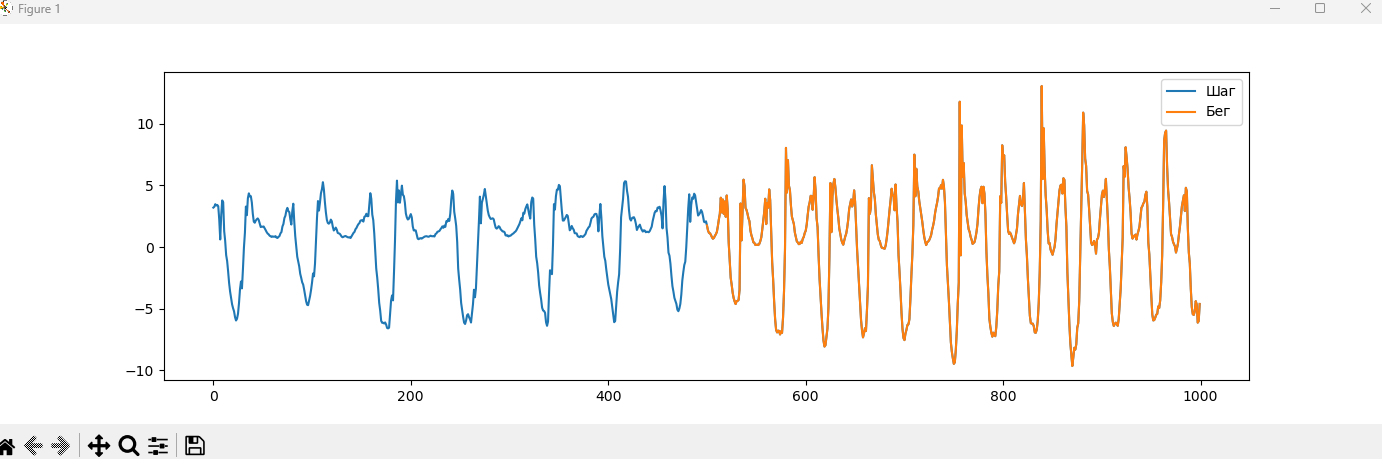

In [6]:
result={}
times={}

##### 3.1.2 Реализация полного перебора

Приводится пример кода для нахождения топ 5 диссонансов с помощью реализации полного беребора.
Вам необходимо добавить код для сбора времени обработки данных.

In [7]:
from modules.saxpy.discord import find_discords_brute_force
start = time()
discords_brute_force= np.stack(find_discords_brute_force(data[:], 50, 5))
end = time()

In [8]:
times['brute_force'] = end - start

print(f"Время выполнения полного перебора: {times['brute_force']} секунд")
print(f"Найденные диссонансы:\n{discords_brute_force}")

Время выполнения полного перебора: 200.68948793411255 секунд
Найденные диссонансы:
[[477.           5.88100934]
 [412.           5.32704317]
 [195.           3.39426635]
 [577.           3.35554403]
 [278.           3.10959389]]


##### 3.1.3 HotSAX

Используя [реализацию](https://github.com/seninp/saxpy/blob/master/saxpy/hotsax.py) найдите топ 5 диссонансов ряда.
Произведите замер времени работы.

In [9]:
import numpy as np
from time import time
from modules.saxpy.hotsax import find_discords_hotsax
from modules.saxpy.discord import find_discords_brute_force

In [11]:
import numpy as np
from time import time
from modules.saxpy.hotsax import find_discords_hotsax
from modules.saxpy.discord import find_discords_brute_force

dataset_dir_path = Path('E:/maga/ryads/pr1/25-Chekrygin-TimeSeriesCourse/practice/03 Discords/datasets')
data_path = dataset_dir_path / 'walk_run.txt'
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

result = {}  #
times = {}   
start_brute = time()  
discords_brute_force = np.stack(find_discords_brute_force(data[:], size_sub, 5))
end_brute = time() 

times['brute_force'] = end_brute - start_brute
result['brute_force'] = discords_brute_force

start_hotsax = time()  
discords_hotsax = find_discords_hotsax(data[:], win_size=50, num_discords=5)
end_hotsax = time()  

times['HOT-SAX'] = end_hotsax - start_hotsax
result['HOT-SAX'] = discords_hotsax

print("Результаты:", result)
print("Время выполнения:", times)


Результаты: {'brute_force': array([[477.        ,   5.88100934],
       [412.        ,   5.32704317],
       [195.        ,   3.39426635],
       [577.        ,   3.35554403],
       [278.        ,   3.10959389]]), 'HOT-SAX': [(477, np.float64(5.881009341683914)), (412, np.float64(5.327043167878002)), (195, np.float64(3.3942663473023327)), (577, np.float64(3.355544027483661)), (278, np.float64(3.10959388763498))]}
Время выполнения: {'brute_force': 196.7798147201538, 'HOT-SAX': 4.9449052810668945}


##### 3.1.4 Визаулизация

Вам необходимо реализовать код позволяющий:
1. Вывести на одном графике ряд и его диссонансы
2. Столбчатую диаграмму времени работы обоих алгоритмов
   
Постройте графики для обоих алгоритмов и сравните полученные результаты.

Пример графика:

![first_graf](pics/fig_ex_1.png)

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(12, 6))

axs[0, 0].plot(data, label='Time Series')
for idx, discord in enumerate(discords_brute_force):
    axs[0, 0].axvspan(discord[0], discord[0] + size_sub, color='blue', alpha=0.3)
    axs[0, 0].text(discord[0], max(data), f'#{idx+1}', fontsize=10, ha='center')
axs[0, 0].plot(data[:], label='Walk')
axs[0, 0].plot(np.arange(data.shape[0]//2, data.shape[0]), data[data.shape[0]//2:], label='Run')
axs[0, 0].set_title('brute_force')
axs[0, 0].legend()

axs[1, 0].plot(data, label='Time Series')
for idx, discord in enumerate(discords_hotsax):
    axs[1, 0].axvspan(discord[0], discord[0] + size_sub, color='red', alpha=0.3)
    axs[1, 0].text(discord[0], max(data), f'#{idx+1}', fontsize=10, ha='center')
axs[1, 0].plot(data[:], label='Walk')
axs[1, 0].plot(np.arange(data.shape[0]//2, data.shape[0]), data[data.shape[0]//2:], label='Run')
axs[1, 0].set_title('brute_force')
axs[1, 0].set_title('hotsax')
axs[1, 0].legend()

axs[0, 1].bar(times.keys(), times.values(), color=['blue', 'red'], alpha=0.5)
axs[0, 1].set_ylabel('Время, с.')
axs[0, 1].set_title('Время выполнения')

fig.delaxes(axs[1, 1])

plt.tight_layout()
plt.show()


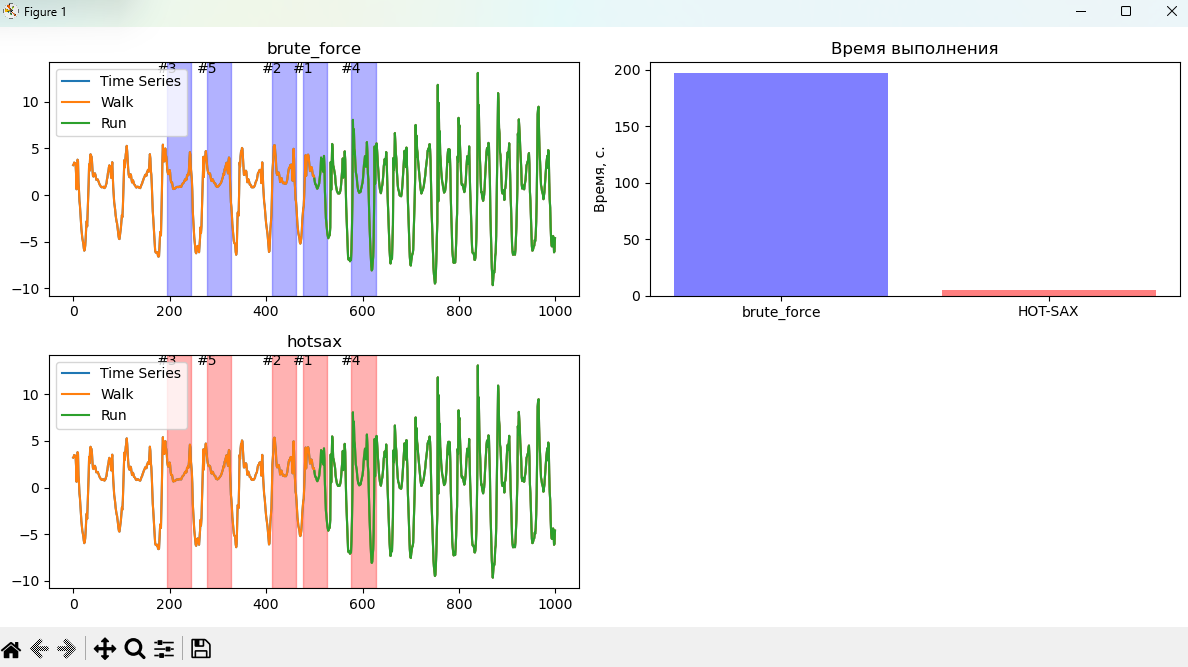

In [13]:
from matplotlib.patches import Rectangle

##### 3.1.5 Такси NY

Произведите поиск диссонансов с помощью обоих алгоритмов на наборе данных, содержащим информацию о среднем числе пассажиров в NY. Отобразите найденные диссонансы обоими алгоритмами. 

In [14]:
nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)
fig = plt.figure(figsize=(18, 4))
plt.plot(nyc_taxi)

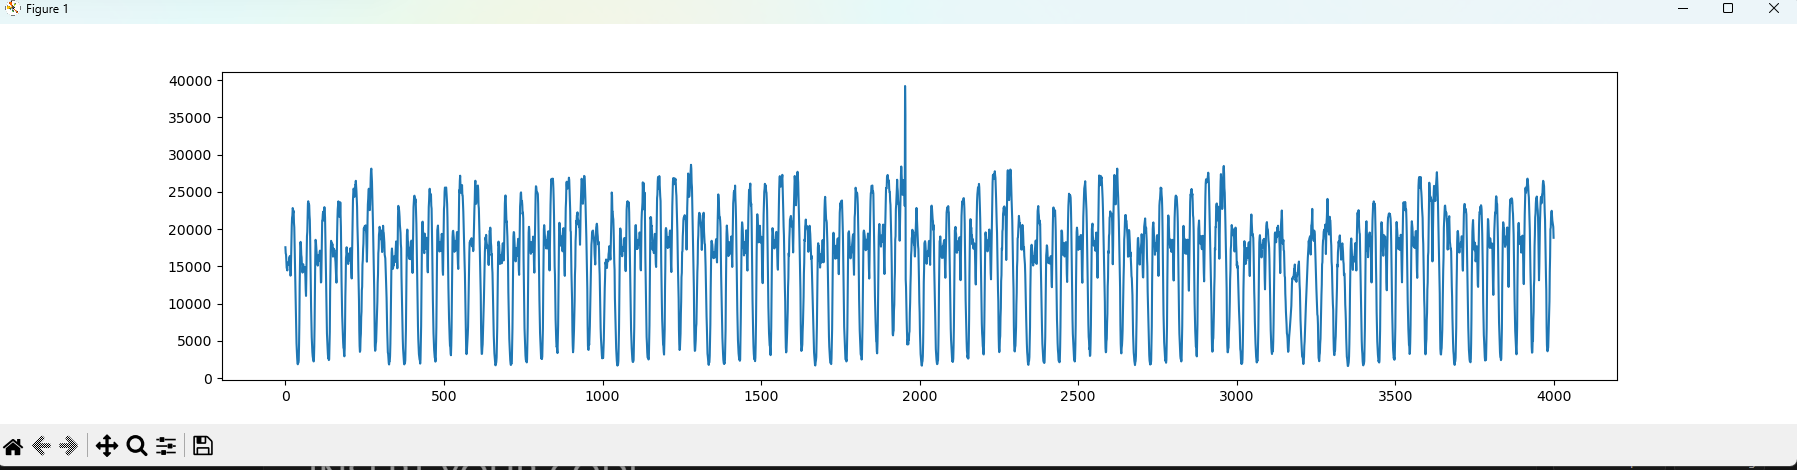

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time import time
from modules.saxpy.hotsax import find_discords_hotsax
from modules.saxpy.discord import find_discords_brute_force
from pathlib import Path

dataset_dir_path = Path('datasets')

nyc_taxi = pd.read_csv(dataset_dir_path / 'nyc_taxi.csv', index_col=0).values[4000:8000, 0].astype(np.float64)

win_size = 50

result_taxi = {}
times_taxi = {}

start_brute = time()
discords_brute_force_taxi = np.stack(find_discords_brute_force(nyc_taxi, win_size, 5))
end_brute = time()

times_taxi['brute_force'] = end_brute - start_brute
result_taxi['brute_force'] = discords_brute_force_taxi

start_hotsax = time()
discords_hotsax_taxi = find_discords_hotsax(nyc_taxi, win_size=win_size, num_discords=5)
end_hotsax = time()

times_taxi['HOT-SAX'] = end_hotsax - start_hotsax
result_taxi['HOT-SAX'] = discords_hotsax_taxi

fig, axs = plt.subplots(2, 2, figsize=(18, 8))

axs[0, 0].plot(nyc_taxi, label='NYC Taxi Time Series')
for idx, discord in enumerate(discords_brute_force_taxi):
    axs[0, 0].axvspan(discord[0], discord[0] + win_size, color='blue', alpha=0.3)
    axs[0, 0].text(discord[0], max(nyc_taxi), f'#{idx+1}', fontsize=10, ha='center')
axs[0, 0].plot(nyc_taxi[:], label='Walk')
axs[0, 0].plot(np.arange(nyc_taxi.shape[0]//2, nyc_taxi.shape[0]), nyc_taxi[nyc_taxi.shape[0]//2:], label='Run')
axs[0, 0].set_title('brute_force')
axs[0, 0].legend()

axs[1, 0].plot(nyc_taxi, label='NYC Taxi Time Series')
for idx, discord in enumerate(discords_hotsax_taxi):
    axs[1, 0].axvspan(discord[0], discord[0] + win_size, color='red', alpha=0.3)
    axs[1, 0].text(discord[0], max(nyc_taxi), f'#{idx+1}', fontsize=10, ha='center')
axs[1, 0].plot(nyc_taxi[:], label='Walk')
axs[1, 0].plot(np.arange(nyc_taxi.shape[0]//2, nyc_taxi.shape[0]), nyc_taxi[nyc_taxi.shape[0]//2:], label='Run')
axs[1, 0].set_title('HOT-SAX')
axs[1, 0].legend()

axs[0, 1].bar(times_taxi.keys(), times_taxi.values(), color=['blue', 'red'], alpha=0.5)
axs[0, 1].set_ylabel('Время, с.')
axs[0, 1].set_title('Время выполнения')

fig.delaxes(axs[1, 1])

plt.tight_layout()
plt.show()

print("Время выполнения методов на данных NYC Taxi:")
print(f"brute_force: {times_taxi['brute_force']} секунд")
print(f"HOT-SAX: {times_taxi['HOT-SAX']} секунд")


Время выполнения методов на данных NYC Taxi:
brute_force: 4062.709702014923 секунд
HOT-SAX: 19.54918670654297 секунд


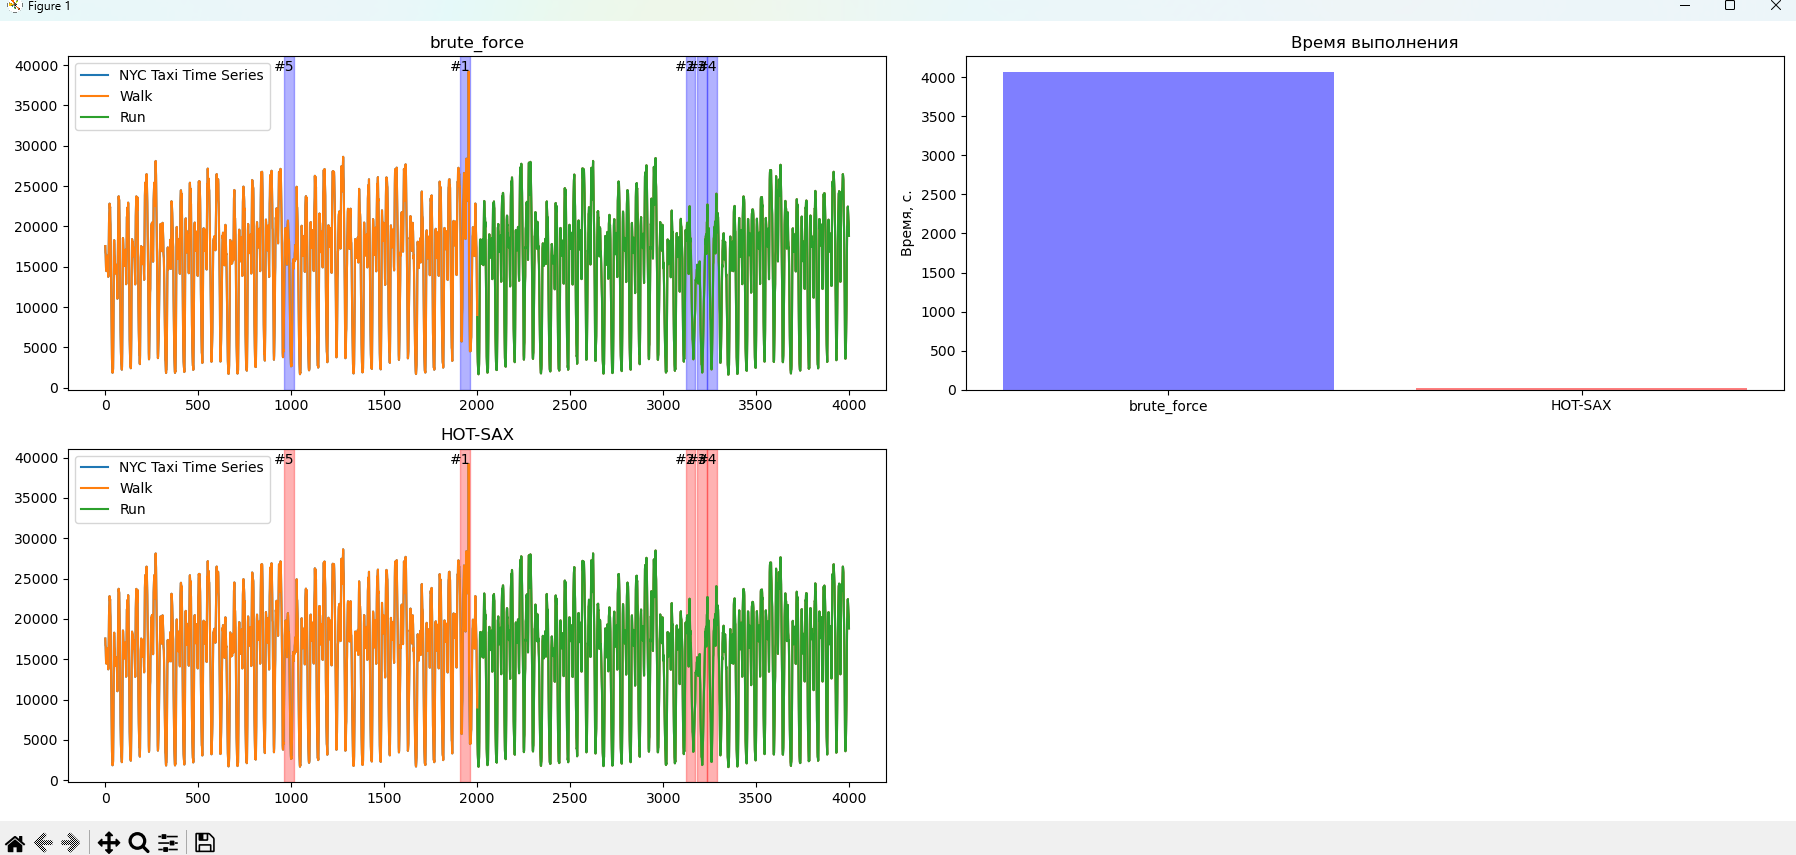

#### **3.2 Поиск диссонансов с помощью алгоритма DRAG**

In [16]:
!pip install stumpy==1.11.1

In [17]:
import stumpy
from stumpy import core, config
from stumpy.scrump import _prescrump


Как мы помним из лекций:

**Диапазонный диссонанс** – подпоследовательность ряда, расстояние от которой до ее ближайшего соседа не ниже заданного порога. 

Основными параметрами при поисках диссонансов являются:
- $m$ - длина диссонанса
- $r$ - пороговое значение расстояния подпоследовательности ряда, до его ближайшего соседа


In [18]:
from modules.drag import find_candidates, DRAG


Для поиска диссонансов в данной части практической работы мы воспользуемся алгоритмом **DRAG (Discord Range Aware Gathering)**.
Для начала воспользуемся данным алгоритмом, чтобы найти диссонансы в наборе данных содержащем активность человека.

In [19]:
data = walk_run

Длину искомого диссонанса, как и для предыдущих алгоритмов, мы установим равно 50 точек.
Пороговое значение мы установим равным большим, чтобы узнать, как алгоритм отреагирует на большие значения данного параметра.

In [22]:
m = 50 
r = 10
idxs, _, _ = DRAG(data,m,r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 0


Как вы можете видеть мы установили слишком большое пороговое значение, алгоритму не удалось выделить ни одного диссонанса. Попробуем уменьшить пороговое значение до 1, чтобы улучшить результат. 

In [10]:
m = 50 
r = 1
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 50


При такой комбинации параметров, улучшить ситуацию не получилось. Алгоритм выделил слишком большое количество диссонансов, часть которых является ложными диссонансами и не будут информативными для нас.

Произведите подобные эксперименты с набором данных такси NY. Постройте графики демонстрирующие найденные диссонансы. Пример Графика:
![second-graph](pics/fig_ex_2.png)

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from modules.drag import DRAG

nyc_taxi = pd.read_csv(dataset_dir_path / 'nyc_taxi.csv', index_col=0).values[4000:8000, 0].astype(np.float64)

m = 50 
r_values = [10, 1]
split_point = len(nyc_taxi) // 2 

def plot_drag_discords(data, m, r_values, split_point):
    fig, axs = plt.subplots(len(r_values), 1, figsize=(18, 6 * len(r_values)), sharex=True)
    
    for i, r in enumerate(r_values):
        step_data = data[:split_point]
        run_data = data[split_point:]
        
        step_idxs, _, _ = DRAG(step_data, m, r)
        run_idxs, _, _ = DRAG(run_data, m, r)
        idxs, _, _ = DRAG(data, m, r)
        print(f'Количество найденных диссонансов для r={r}: {len(idxs)}')
        
        axs[i].plot(step_data, label="Шаг", color='blue')
        for idx in step_idxs:
            axs[i].axvspan(idx, idx + m, color='blue', alpha=0.3)

        axs[i].plot(np.arange(split_point, len(data)), run_data, label="Бег", color='orange')
        for idx in run_idxs:
            axs[i].axvspan(split_point + idx, split_point + idx + m, color='red', alpha=0.3) 

        axs[i].set_title(f'DRAG Discords (r = {r})')
        axs[i].legend()
    
    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()

plot_drag_discords(nyc_taxi, m, r_values, split_point)


Количество найденных диссонансов для r=10: 0
Количество найденных диссонансов для r=1: 42


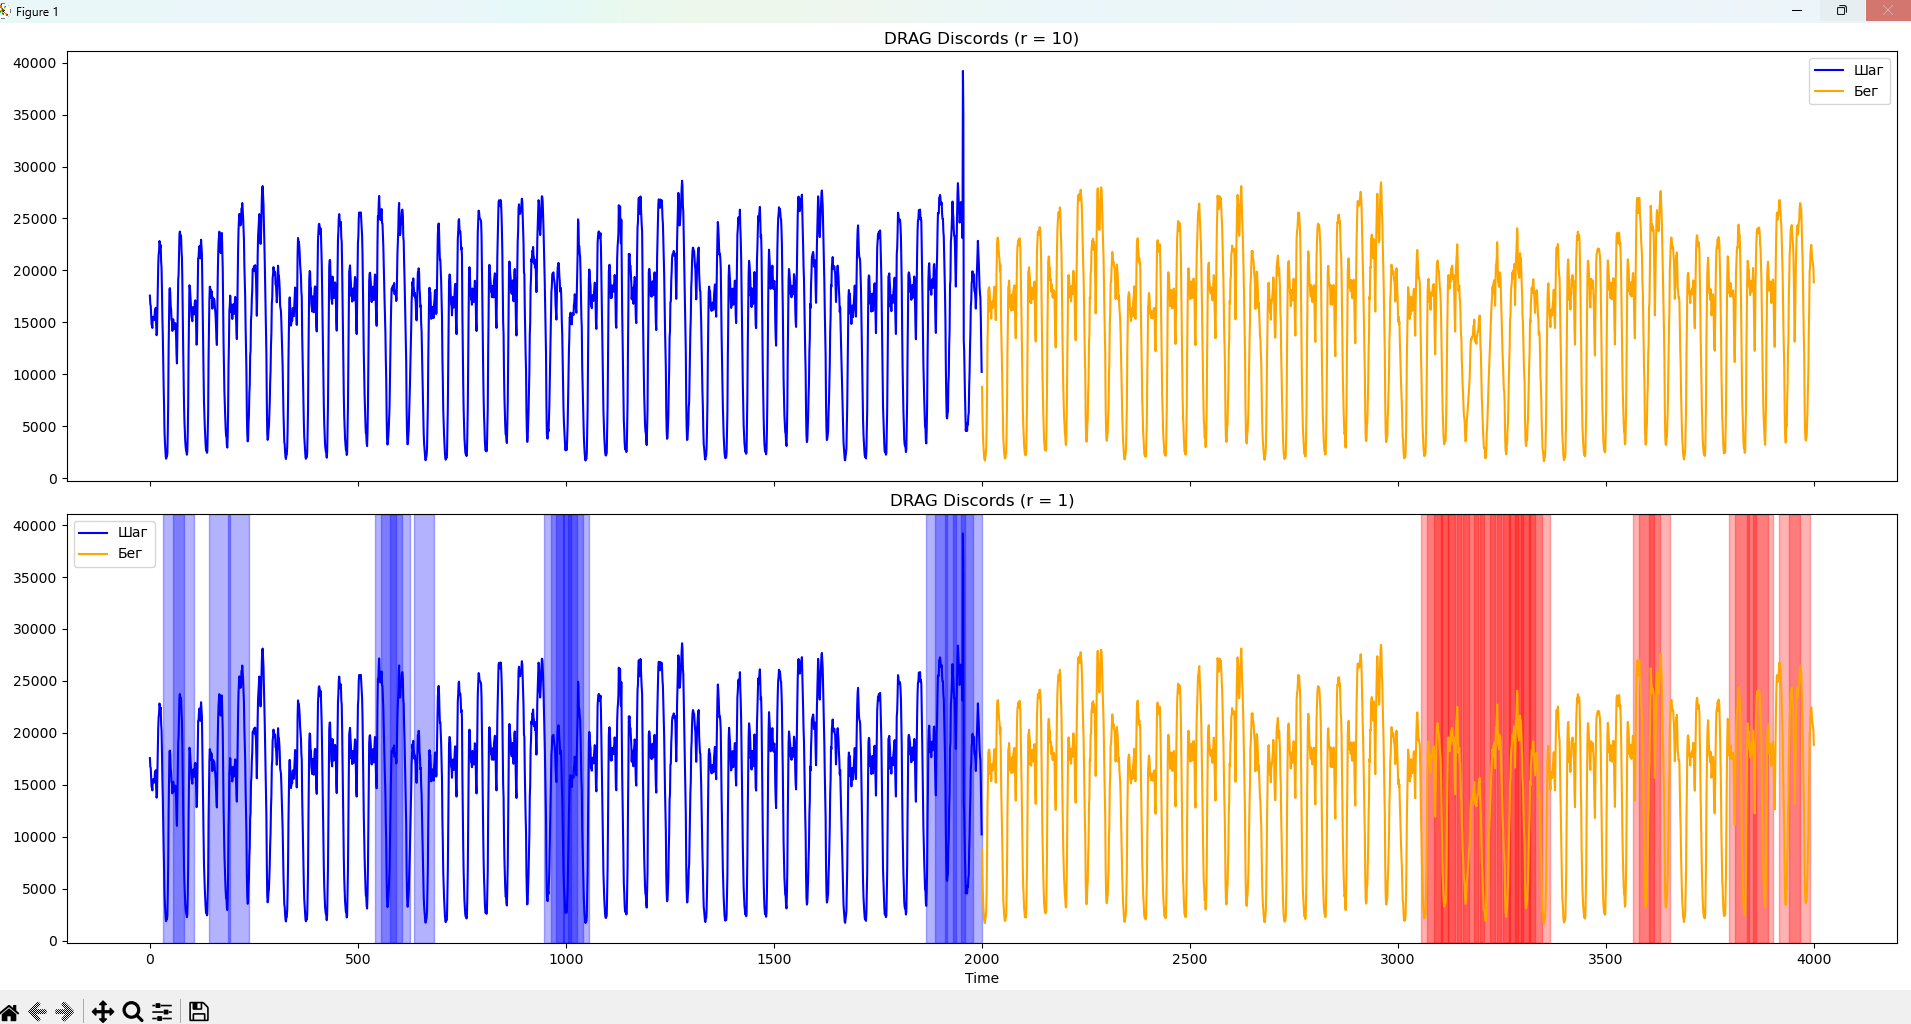

Чтобы разобраться, почему так происходит и как работает данный алгоритм, ниже мы реализуем все этапы алгоритма DRAG.

Как мы помним из лекций алгоритм DRAG содержит два этапа:

1. Отбор - За одно сканирование ряда сформировать множество кандидатов в диссонансы.
2. Очистка - За одно сканирование ряда отбросить кандидатов, которые являются ложными диссонансами.

##### 3.2.1 Отбор кандидатов

Первым этапом обработки данных является отбор множества потенциальных кандидатов. Мы выбираем из всего множества подпоследовательностей ряда такие, для которых расстояние до правых ближайших соседей больше параметра $r$.

In [29]:
#выбирем более реальное значение для порога
r = 3

In [30]:
T, M_T, Σ_T = core.preprocess(data, m)
#формируем массив длинной равной длине  исходного ряда - m + 1, 
#элемент массива является истинным, 
#в том случае если подпоследовательность является потенциальным кандидатом
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
#находим индексы потенциальных кандидатов
cand_index = np.flatnonzero(is_cands)

In [31]:
print(f'{len(cand_index)} {len(cand_index)/len(data)*100} %')

113 11.3 %


Во время отбора кандидатов нам удалось выделить около 113 подпоследовательностей(около 11.3%), которые мы бы могли назвать потенциальными диссонансами.
Это большой процент, который не может нас устраивать как конечный результат.
Если посмотреть на рисунок ниже, мы увидим, что большая часть потенциальных диссонансов расположена в районе смены активности. 
К сожалению пресутсвуют и ложные диссонансы, которые случайным образом попали в данный список.

Сформируйте график найденных диссонансов

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stumpy import core
from modules.drag import find_candidates

data = walk_run  

m = 50 
r = 3  

T, M_T, Σ_T = core.preprocess(data, m)

is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)

cand_index = np.flatnonzero(is_cands)
print(f'{len(cand_index)} кандидатов ({len(cand_index)/len(data)*100:.2f} % от длины ряда)')

plt.figure(figsize=(18, 6))

plt.plot(data, label='Временной ряд')

for idx in cand_index:
    plt.axvspan(idx, idx + m, color='green', alpha=0.3)

plt.title(f'Кандидаты на диссонансы (r = {r})')
plt.legend()
plt.show()


113 кандидатов (11.30 % от длины ряда)


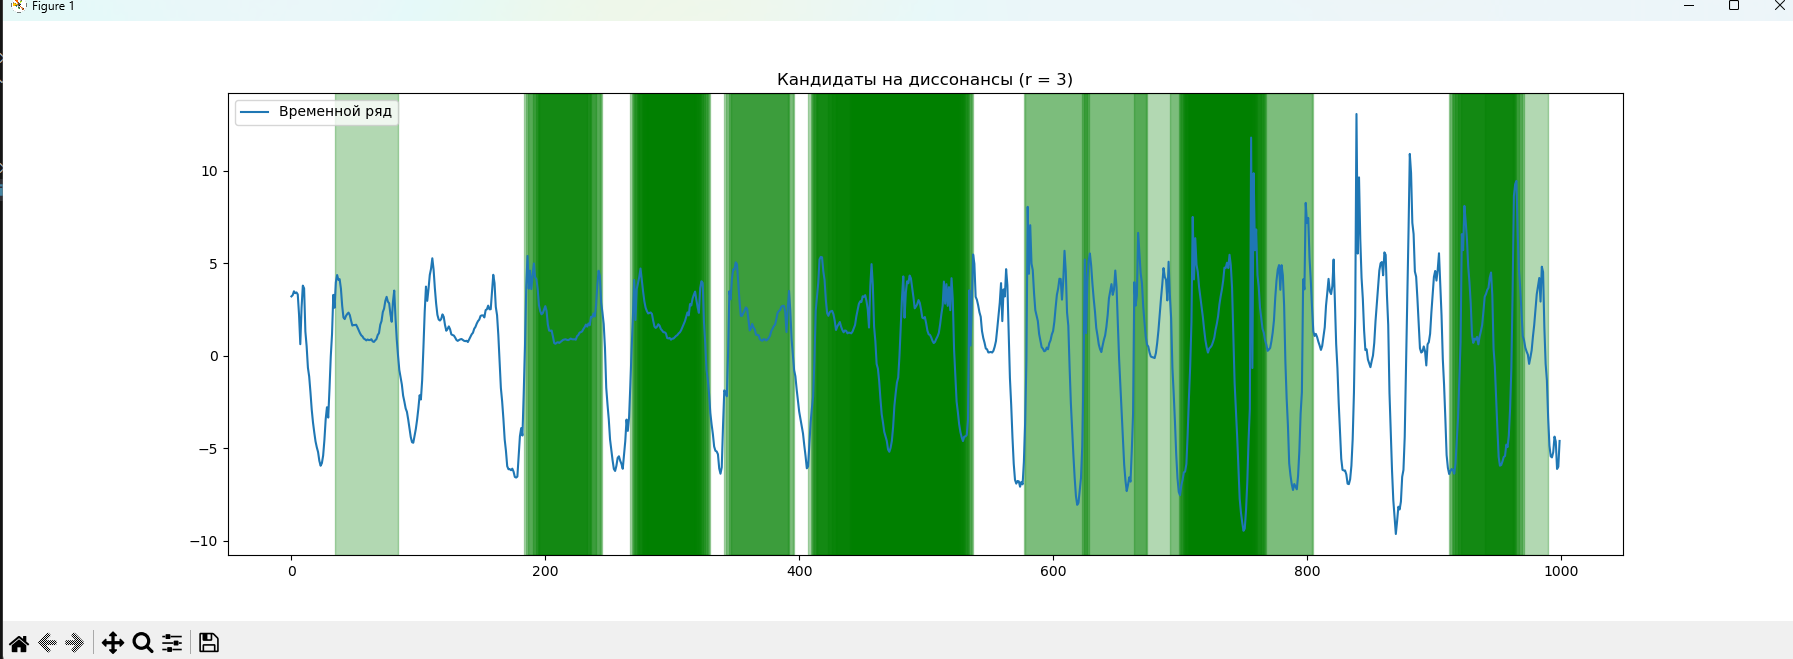

##### 3.2.2 Очистка кандидатов
Как уже упоминалось выше, 11.3% слишком большой процент диссонансов.
Для уменьшения числа потенциальных кандидатов произведем очистку от ложных диссонансов, путем сравнения расстояния до левых ближайших соседей потенциальных диссонансов с порогом $r$.


In [33]:
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
cands = np.flatnonzero(is_cands)

In [34]:
len(cands)/len(data)*100

2.9000000000000004

Сформируйте график найденных диссонансов

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from stumpy import core
from modules.drag import find_candidates

data = walk_run 

m = 50
r = 3   

T, M_T, Σ_T = core.preprocess(data, m)

is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)

is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)

cands = np.flatnonzero(is_cands)
print(f'{len(cands)} кандидатов ({len(cands)/len(data)*100:.2f} % от длины ряда)')

plt.figure(figsize=(18, 6))

plt.plot(data, label='Временной ряд')

for idx in cands:
    plt.axvspan(idx, idx + m, color='red', alpha=0.3)  

plt.title(f'Очищенные диссонансы (r = {r})')
plt.legend()
plt.show()


29 кандидатов (2.90 % от длины ряда)


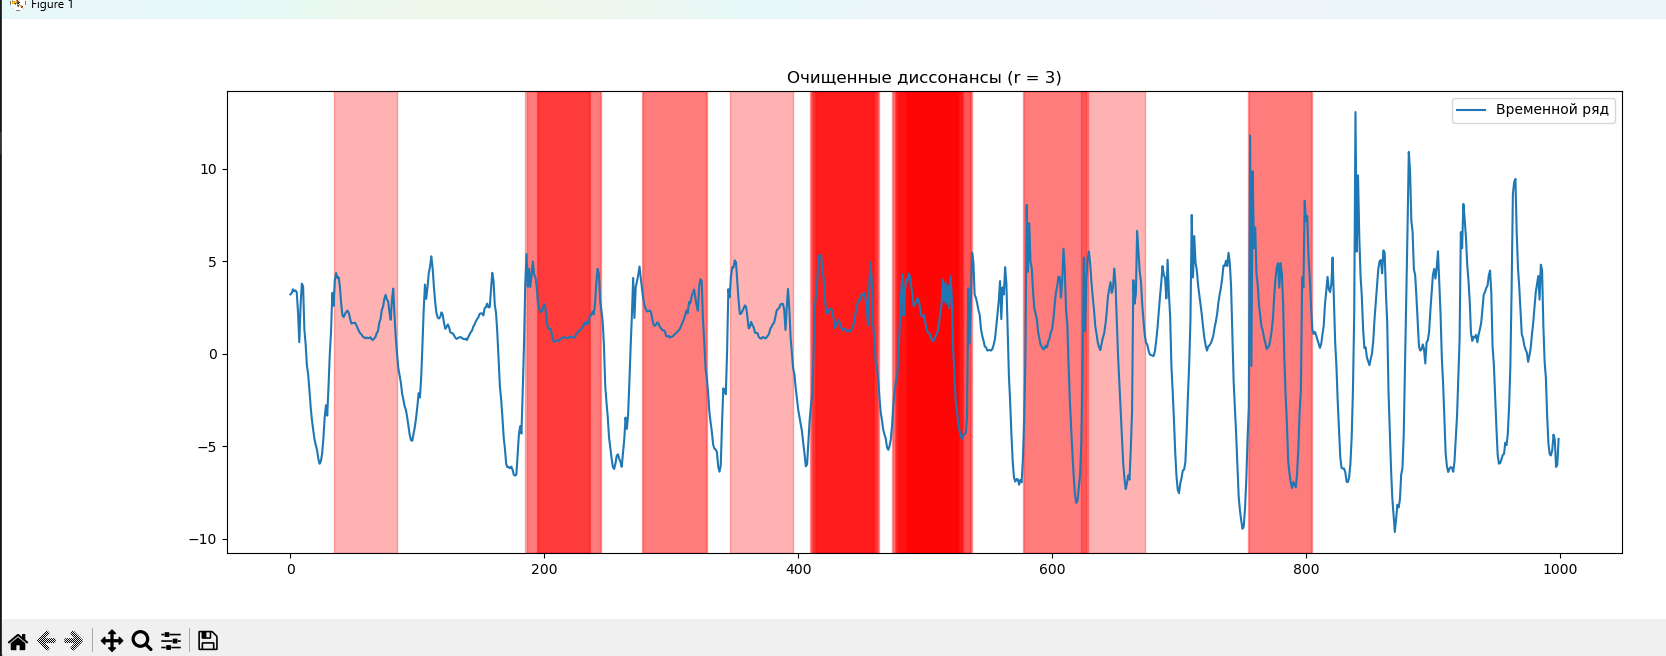

Нам удалось сократить число диссонансов до 2.9%. Если проанализировать рисунок, то можно заметить, что большая их часть является тривиальными повторениями подпоследовательности в области смены активности. На следующем шаге избавимся от них.

In [36]:
from modules.drag import refine_candidates
discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)
len(discords_idx)/len(data)*100

0.8999999999999999

Сформируйте график найденных диссонансов

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from stumpy import core
from modules.drag import find_candidates, refine_candidates

data = walk_run  

m = 50
r = 3   

T, M_T, Σ_T = core.preprocess(data, m)

is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)

discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)
print(f'{len(discords_idx)} диссонансов ({len(discords_idx)/len(data)*100:.2f} % от длины ряда)')

plt.figure(figsize=(18, 6))

plt.plot(data, label='Временной ряд')

for idx in discords_idx:
    plt.axvspan(idx, idx + m, color='red', alpha=0.3) 

plt.title(f'Окончательные диссонансы (r = {r}) после очистки')
plt.legend()
plt.show()


9 диссонансов (0.90 % от длины ряда)


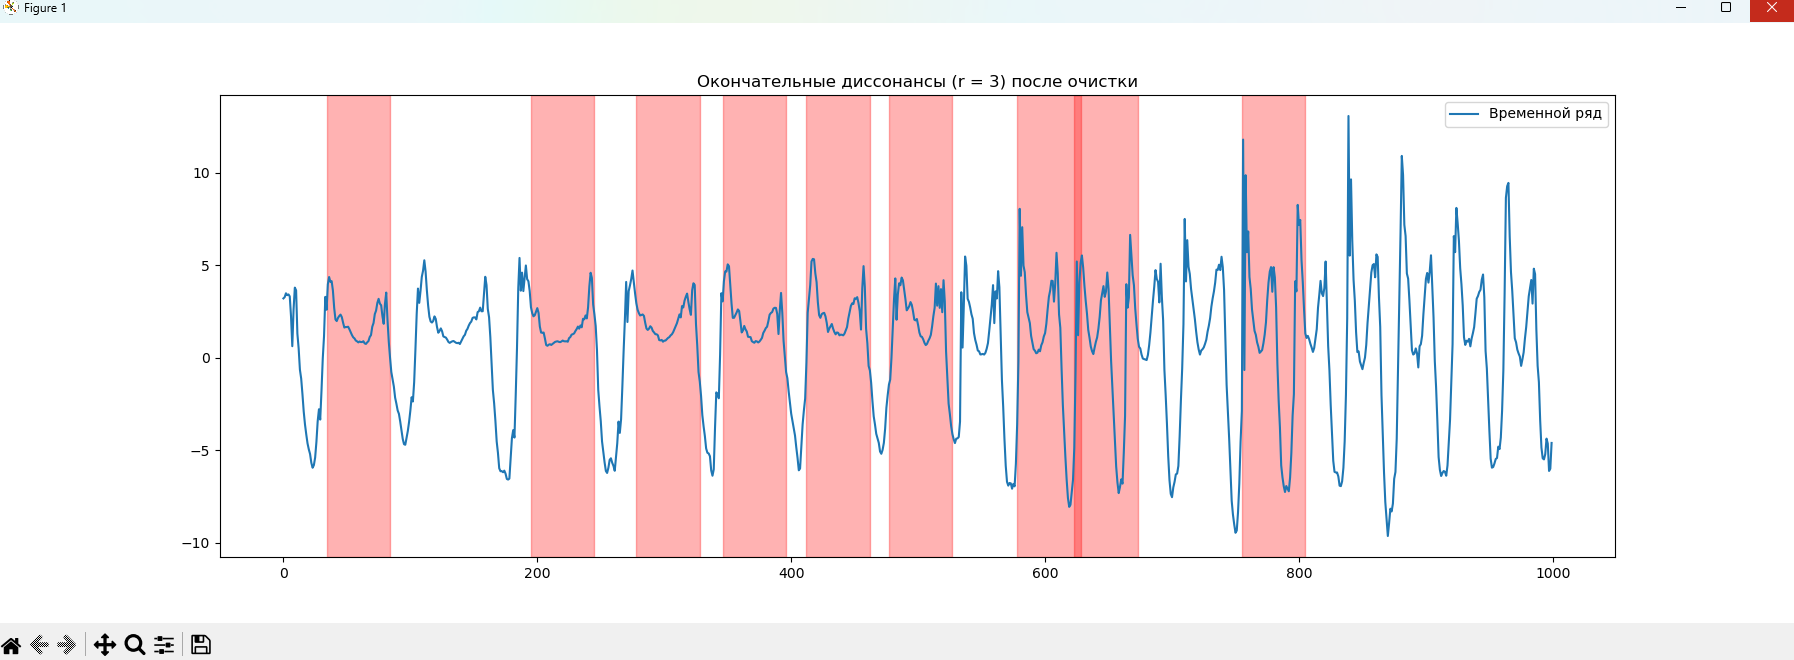

##### 3.2.3 Подбор параметров

Реализуйте перебор параметров $m$ и $r$. Подберете параметры таким образом, чтобы алгоритм обнаружил только те диссонансы, которые связаны со сменой активности. Сделайте вывод о том, как эти параметры влияют на качество работы модели.
Подберите оптимальные параметры алгоритма для набора данных такси NY. 
Визуализируйте результаты для разных комбинаций. Сделайте выводы.


In [38]:
import matplotlib.pyplot as plt
import numpy as np
from stumpy import core
from modules.drag import find_candidates, refine_candidates

data = nyc_taxi 

m_values = [30, 50, 70] 
r_values = [1, 2, 3, 5]

def plot_discords(data, discords_idx, m, r):
    plt.figure(figsize=(18, 6))
    plt.plot(data, label='Временной ряд')
    for idx in discords_idx:
        plt.axvspan(idx, idx + m, color='red', alpha=0.3) 
    plt.title(f'DRAG Discords (m = {m}, r = {r})')
    plt.legend()
    plt.show()

for m in m_values:
    for r in r_values:
        T, M_T, Σ_T = core.preprocess(data, m)

        is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
        is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)

        discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)

        print(f'Параметры m={m}, r={r} -> Найдено {len(discords_idx)} диссонансов ({len(discords_idx)/len(data)*100:.2f} % от длины ряда)')

        plot_discords(data, discords_idx, m, r)


Параметры m=30, r=1 -> Найдено 58 диссонансов (1.45 % от длины ряда)
Параметры m=30, r=2 -> Найдено 12 диссонансов (0.30 % от длины ряда)
Параметры m=30, r=3 -> Найдено 2 диссонансов (0.05 % от длины ряда)
Параметры m=30, r=5 -> Найдено 1 диссонансов (0.03 % от длины ряда)
Параметры m=50, r=1 -> Найдено 42 диссонансов (1.05 % от длины ряда)
Параметры m=50, r=2 -> Найдено 8 диссонансов (0.20 % от длины ряда)
Параметры m=50, r=3 -> Найдено 4 диссонансов (0.10 % от длины ряда)
Параметры m=50, r=5 -> Найдено 0 диссонансов (0.00 % от длины ряда)
Параметры m=70, r=1 -> Найдено 62 диссонансов (1.55 % от длины ряда)
Параметры m=70, r=2 -> Найдено 15 диссонансов (0.38 % от длины ряда)
Параметры m=70, r=3 -> Найдено 8 диссонансов (0.20 % от длины ряда)
Параметры m=70, r=5 -> Найдено 1 диссонансов (0.03 % от длины ряда)


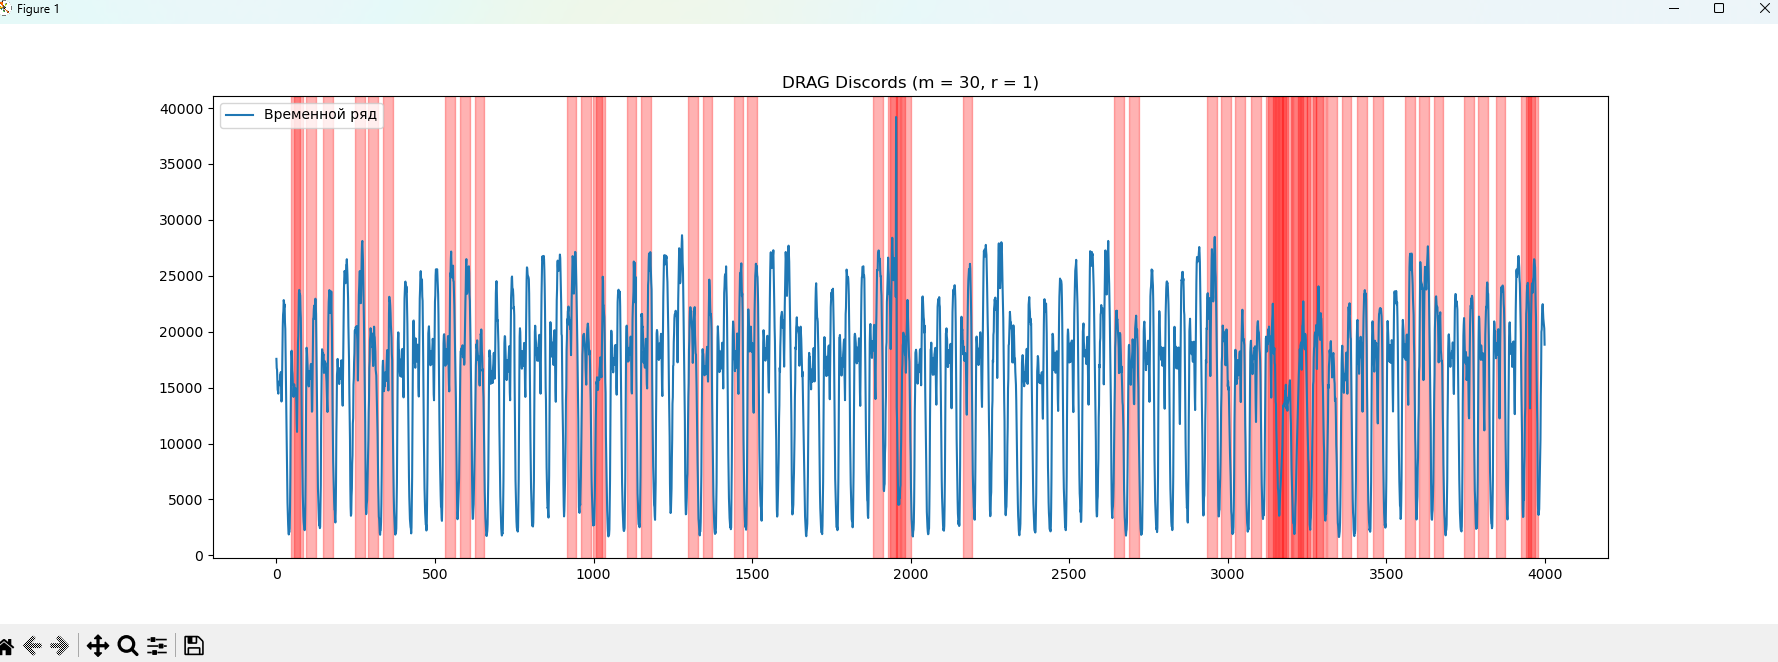

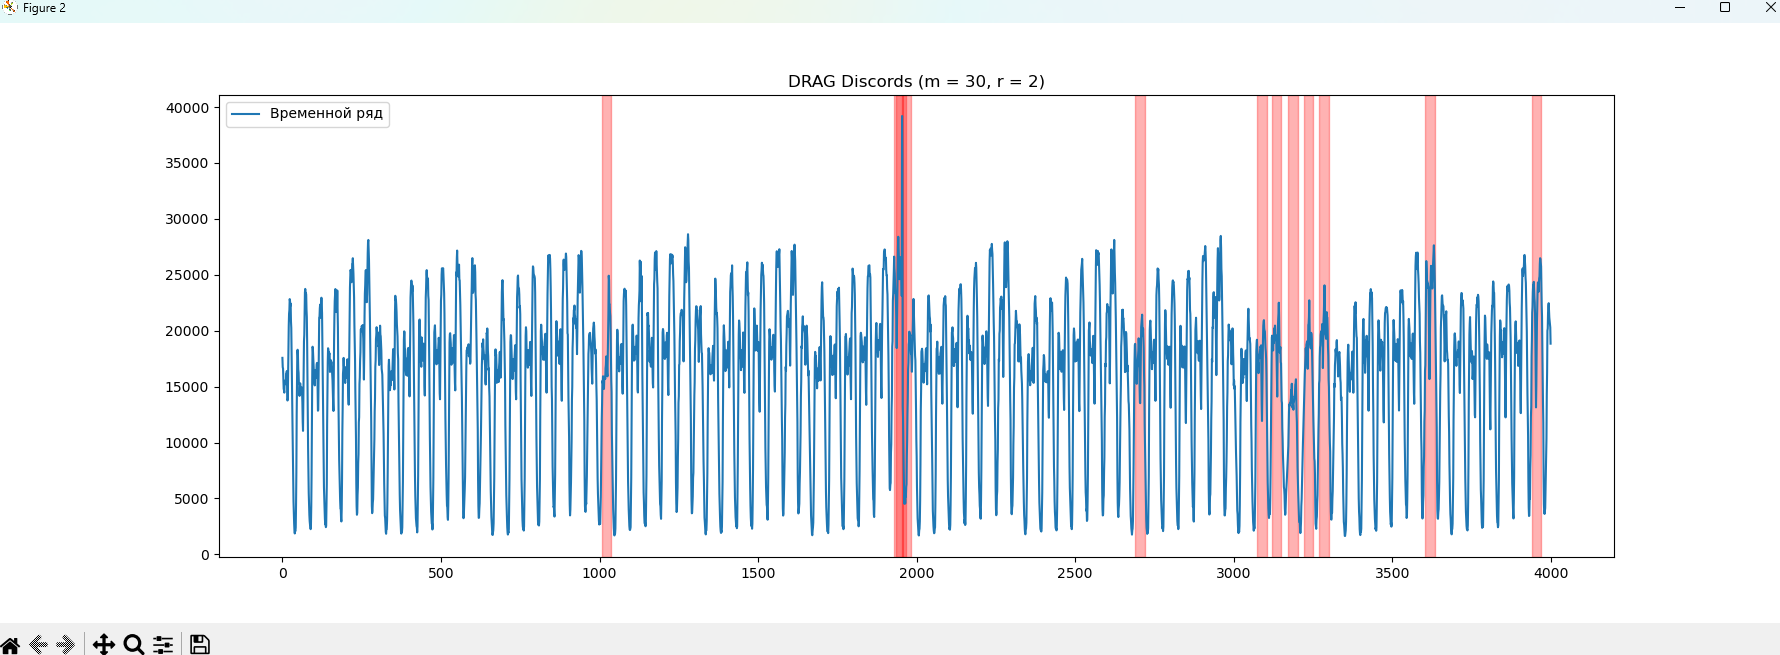

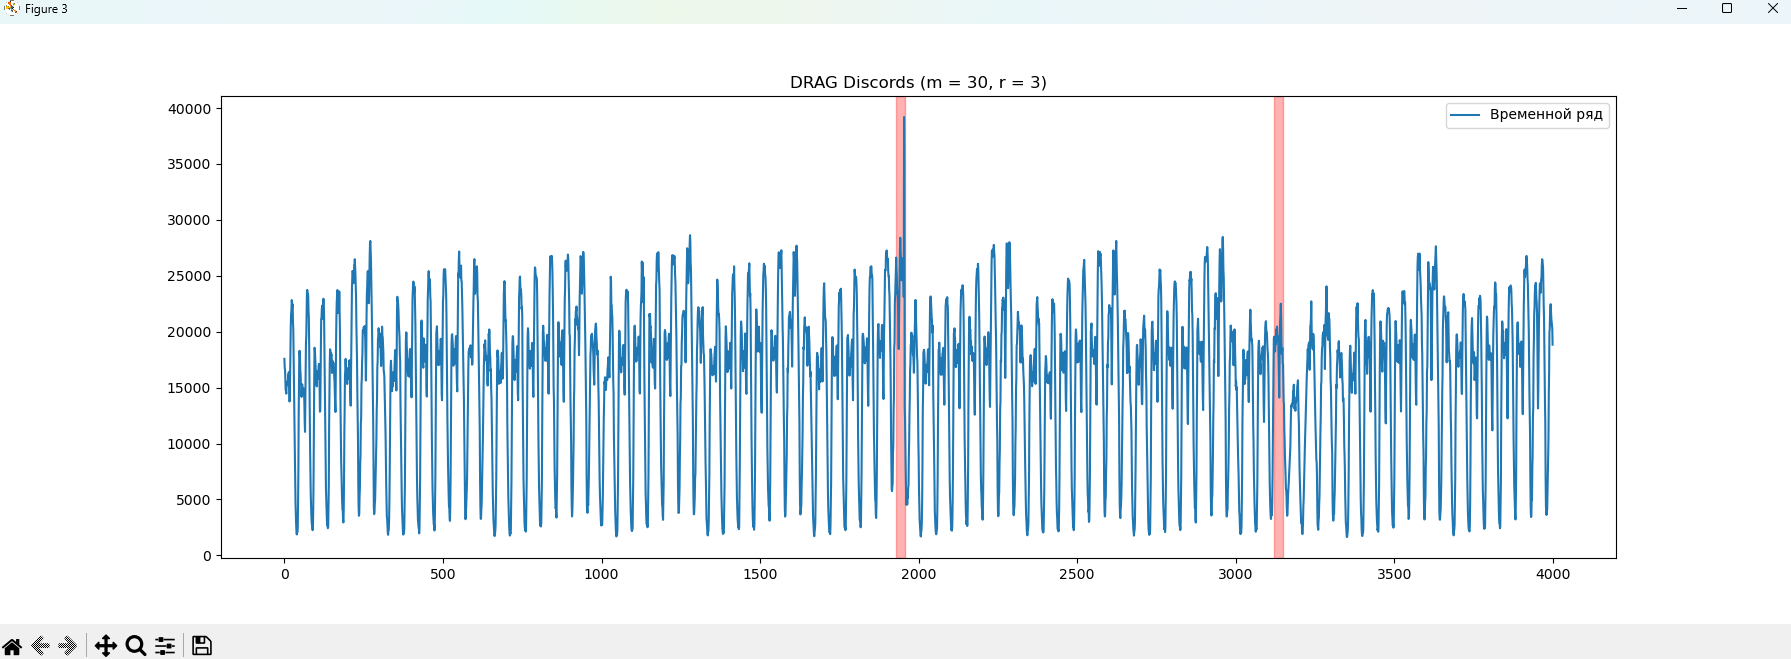

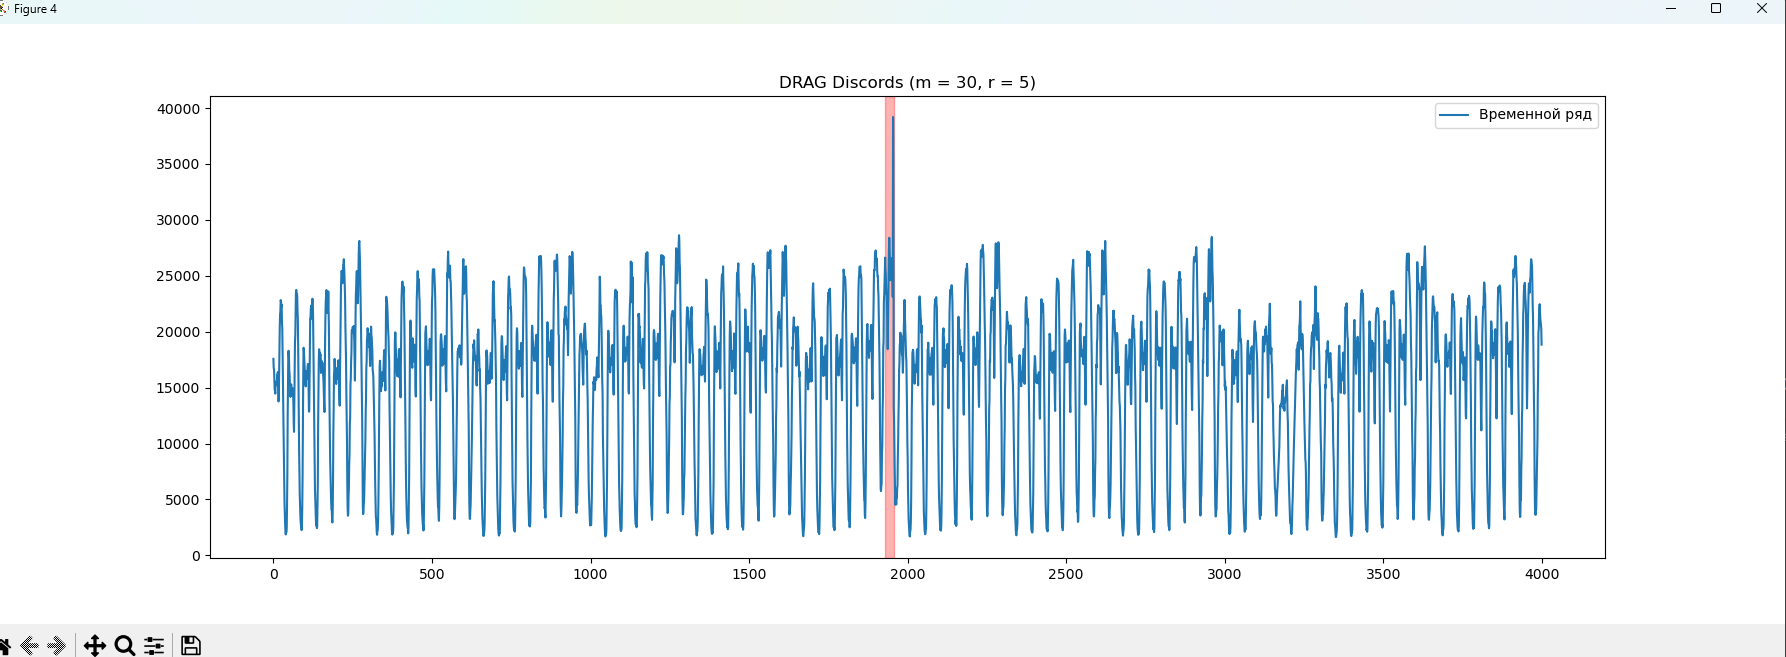

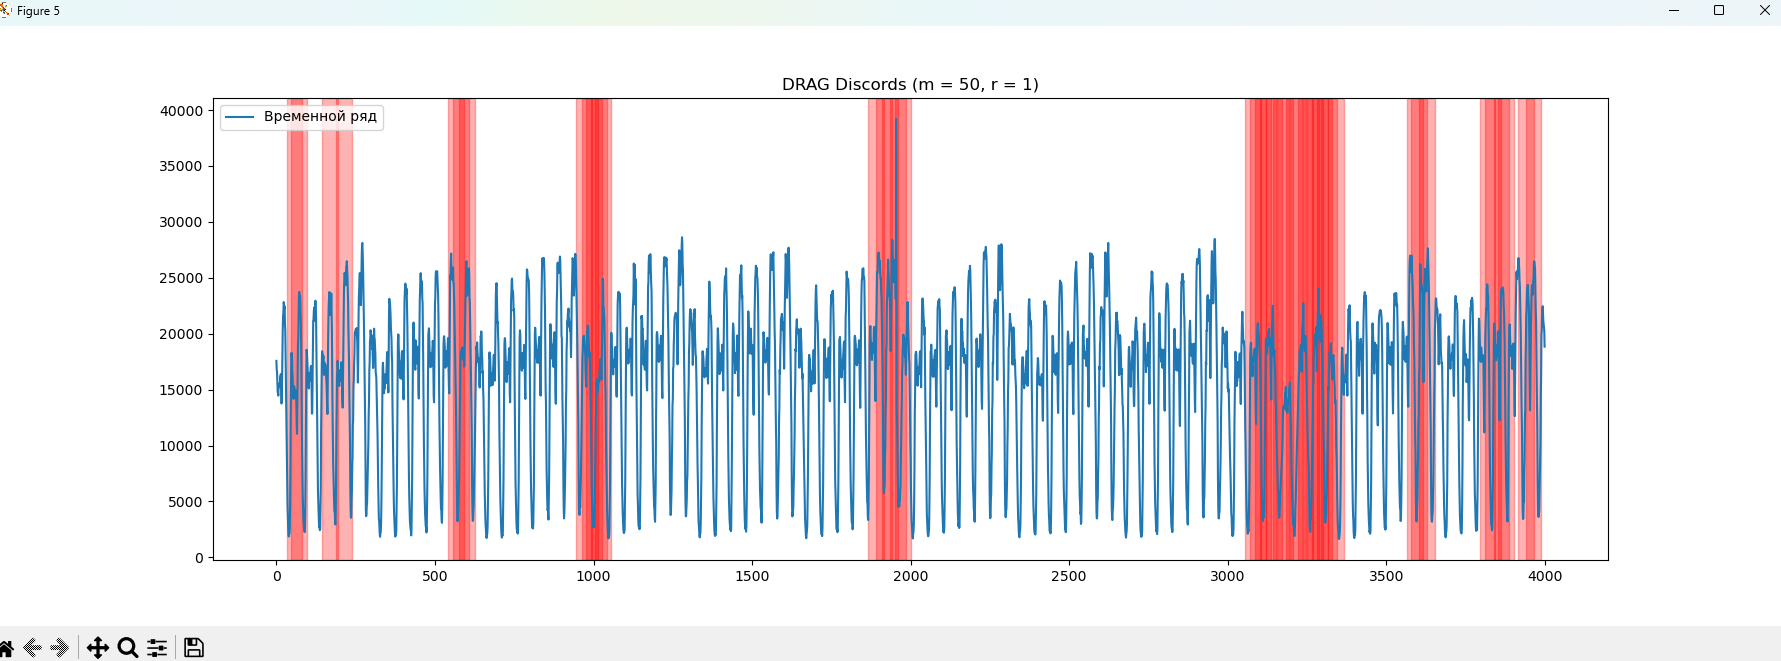

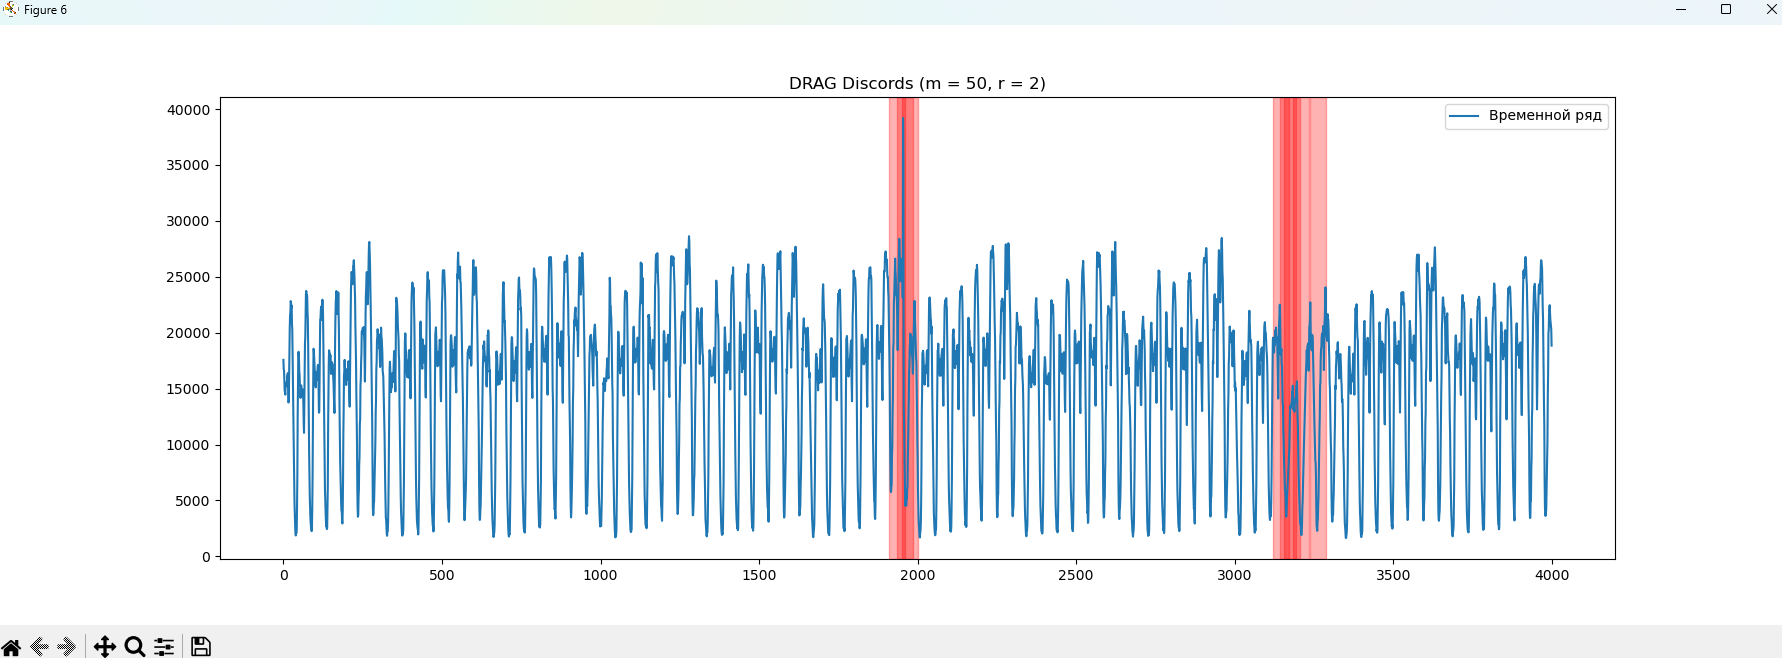

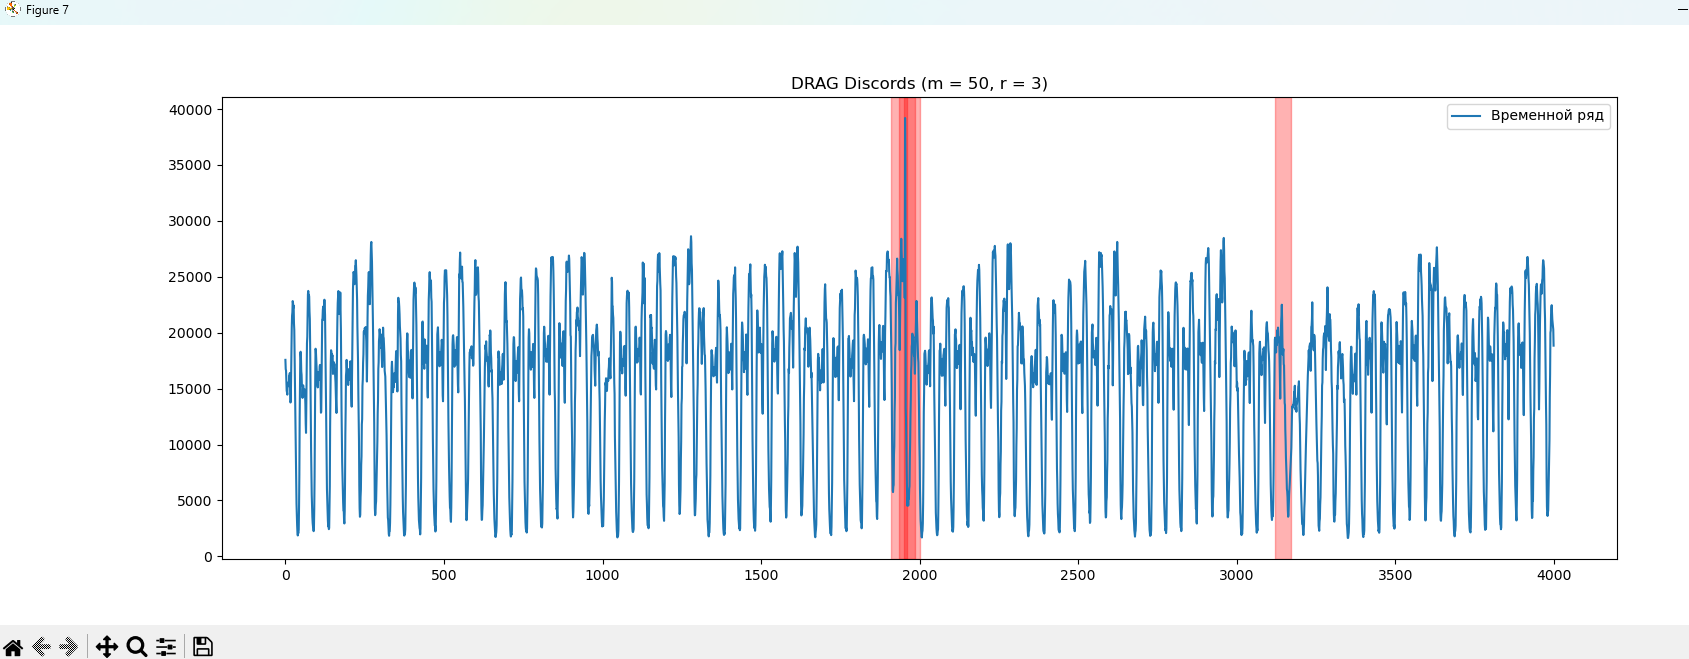

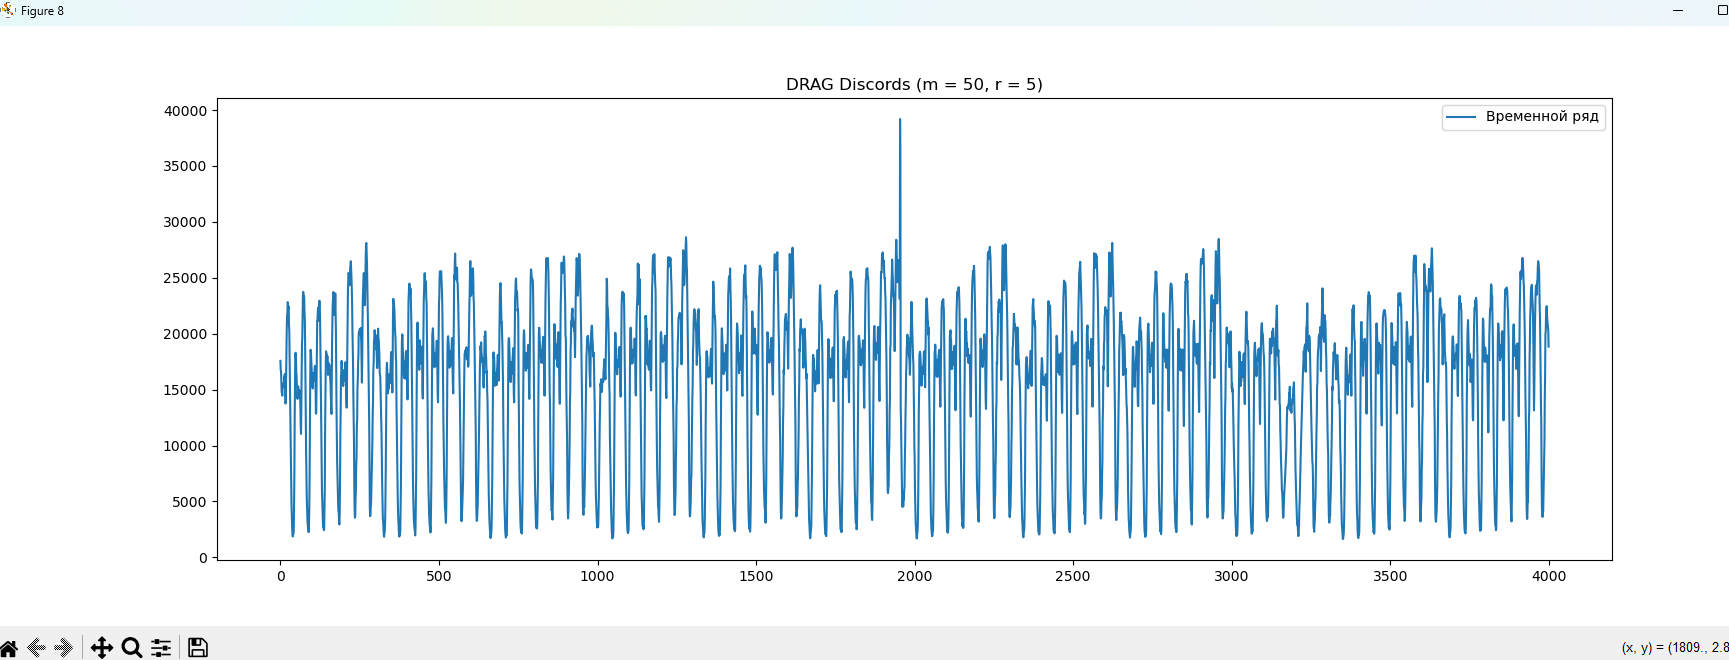

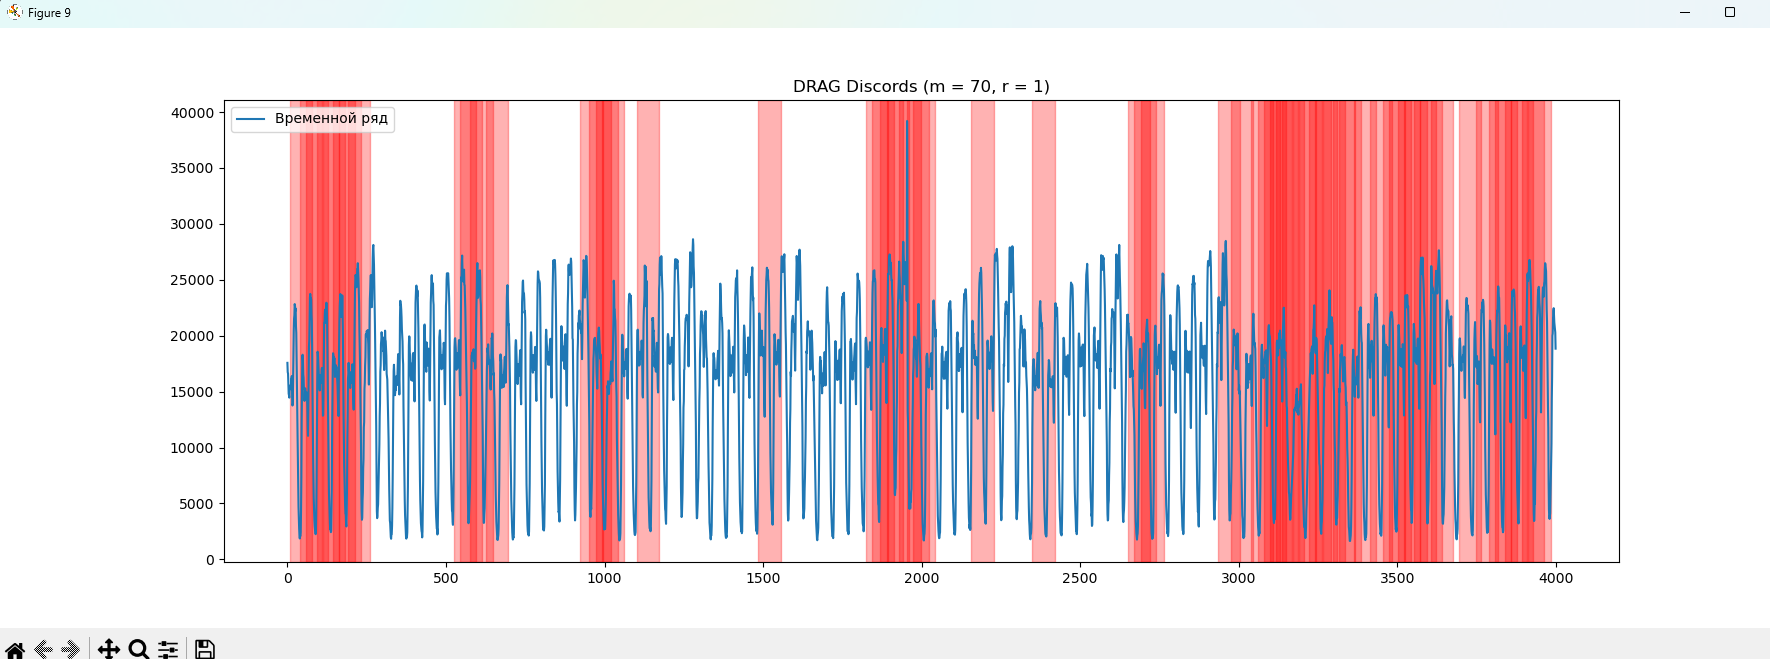

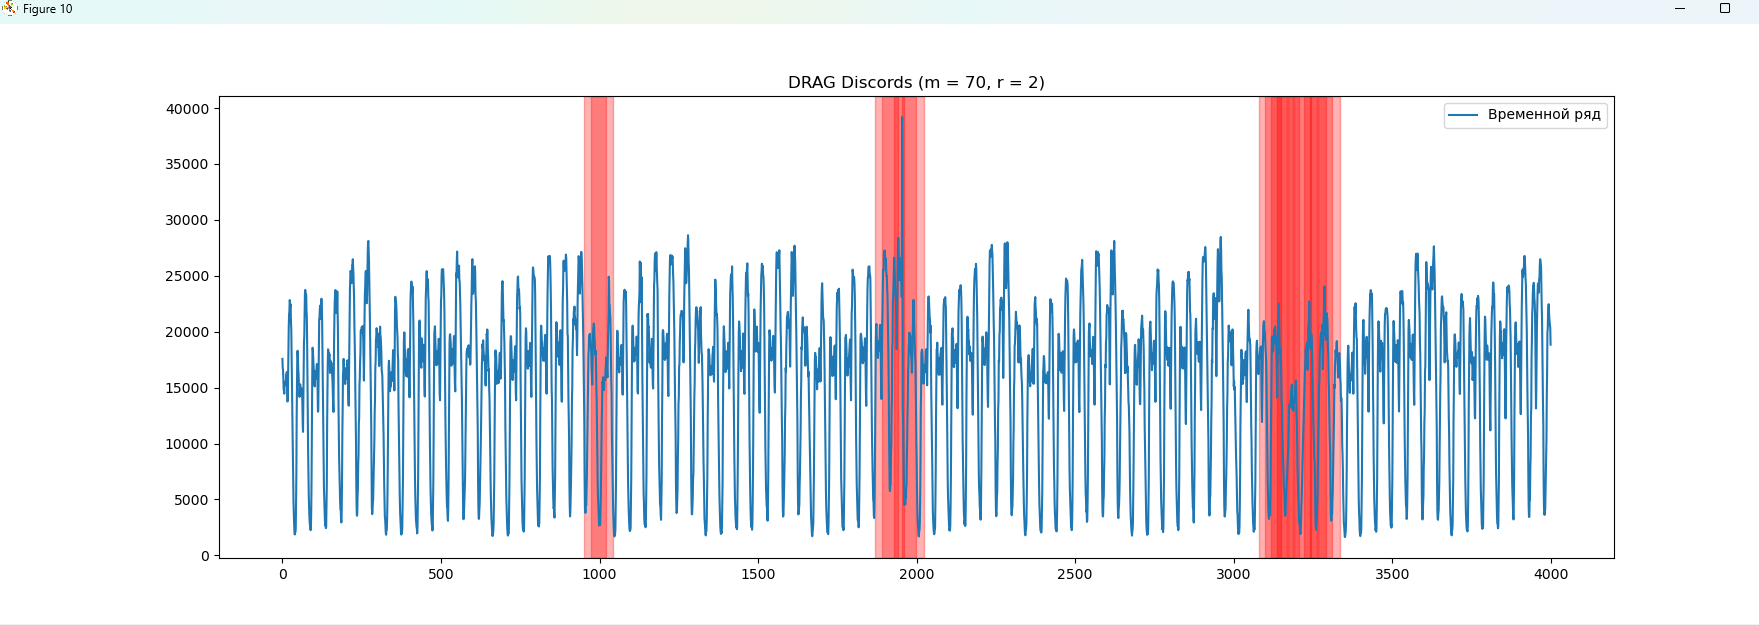

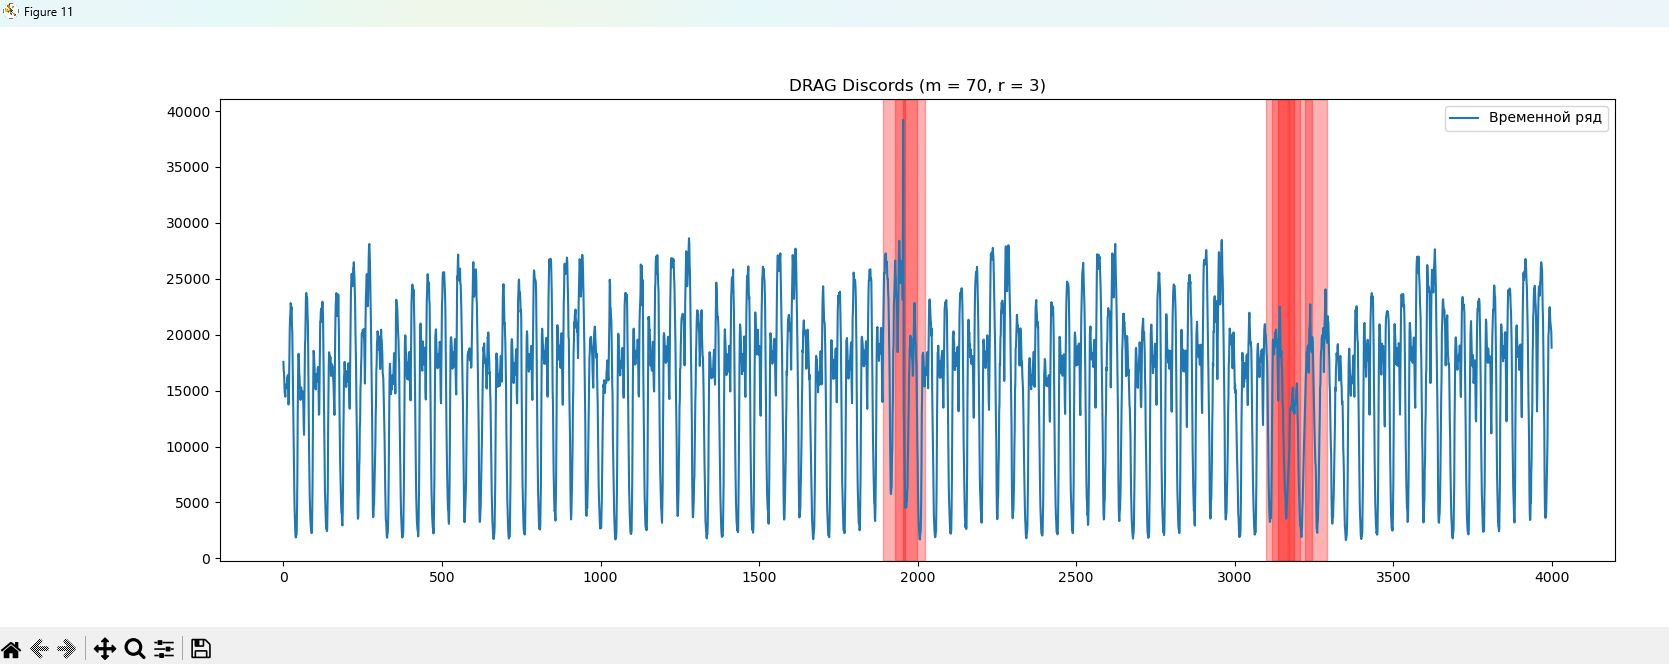

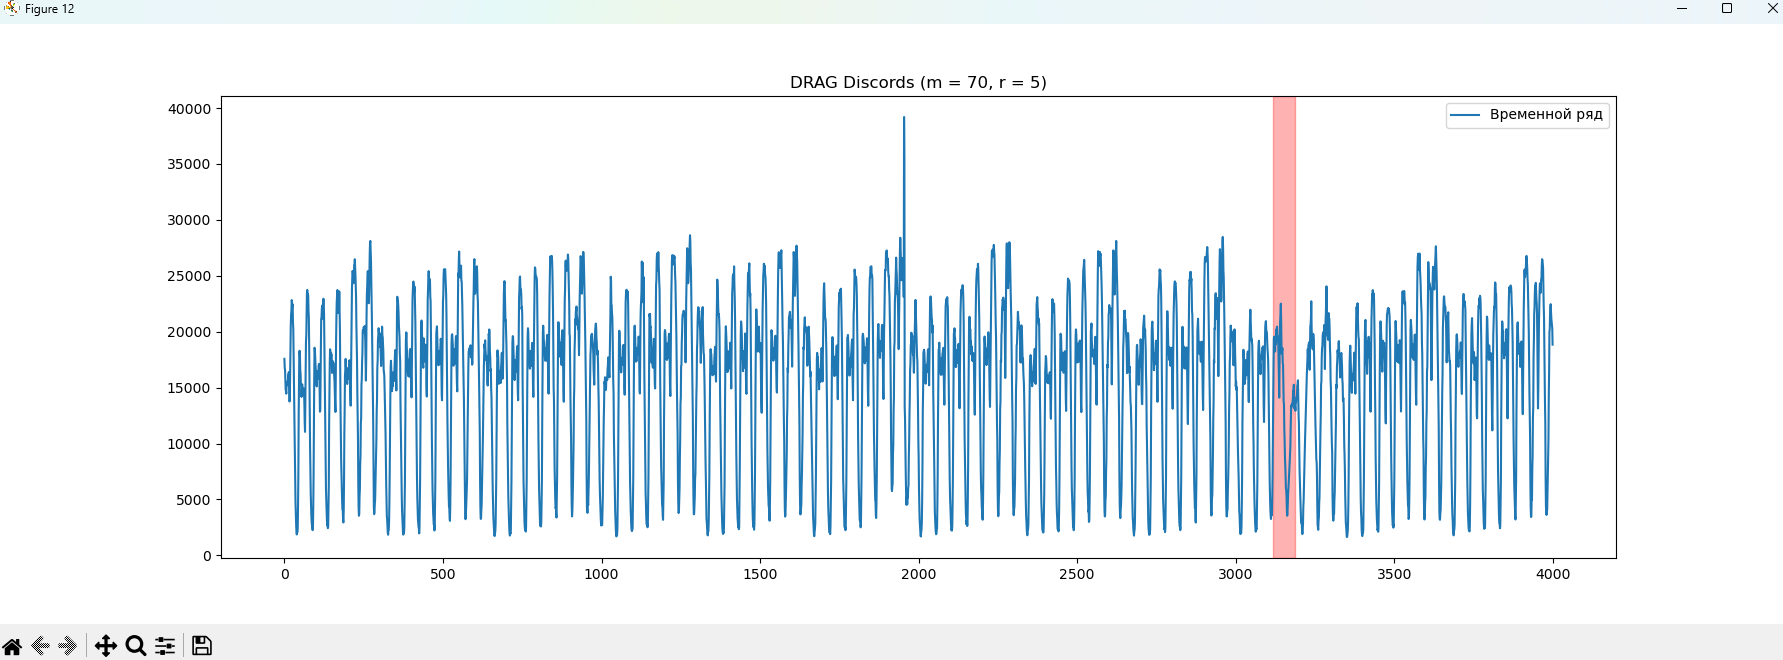

Маленькие окна ловят мелкие аномалии, большие — более крупные. Порог r контролирует строгость обнаружения: низкий r даёт много кандидатов, высокий — остаются только ярко выраженные аномалии.

#### **3.3 Поиск диссонансов с помощью алгоритма Merlin**

Как мы уже выяснили подбирать параметры для DRAG простым перебором не очень удобно. Для оптимизации данного процесса в статье [1] был предложен алгоритм Merlin для оптимального поиска подходящего порогового значения.

Условно мы можем разделить поиск диссонансов на три шага:

1. Поиск диссонансов минимальной длинны $minL$. На данном шаге $r = 2\sqrt{minL}$.
2. Поиск диссонансов следующих четырех длин. На данном шаге $r = 0.99 \cdot nndist_{m-1}$. Где $nndist_{m-1}$ - расстояние до ближайшего соседа предыдущего найденного диссонанса.
3. Поиск диссонансов всех 
оставшихся дли. $r = \mu - 2 \sigma$. Средние значение и стандартное отклонение вычисляются из расстояний 5 предыдущих диссонансов. н

[1] Nakamura T., Imamura M., Mercer R., Keogh E.J. MERLIN: parameter-free discovery of arbitrary length anomalies in massive time series archives. 20th IEEE Int. Conf. on Data Mining, ICDM 2020, Sorrento, Italy, November 17-20, 2020. pp. 1190-1195. IEEE (2020). https://doi.org/10.1109/ICDM50108.2020.00147

##### 3.3.1 Поиск диссонансов минимальной длинны

Вспомнил последовательность действий первого шага алгоритма:
![merlin-part-first](pics/first_part.png)

В данной работе мы внесем небольшое изменение, мы будем считать, что подпоследовательность может быть диссонансом только в том случае, если больше 75% точек, не входят в состав других диссонансов. 

In [39]:
T = walk_run
m = 50
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса, 
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 10


In [40]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        #исключаем окружающие найденный диссонас 
        #подпоследовательности и числа потенциальных диссонасов
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [41]:
maxL

55

In [42]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

Количество найденных на первом этапе диссонансов: 2


На первом шаге нам удалось выделить 2 диссонанса из 10 требуемых. 
Реализуйте, оставшиеся шаги алгоритма, чтобы найти оставшиеся диссонансы. 

![merlin-part-first](pics/second_part.png)


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from stumpy import core
from modules.drag import DRAG

T = walk_run 
m = 50
topK = 10

excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)

dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = -np.ones((topK))

r = 2*np.sqrt(m)
minL = m
maxL = int(m + np.ceil(m*0.1))
cound_find_dis = 0

while cound_find_dis < topK:
    result = DRAG(data=T, m=minL, r=r, include=include)
    for diss, nnDist, nn in zip(*result):
        if cound_find_dis >= topK:
            break
        if nnDist < 0:
            continue
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis += 1
    r *= 0.5
    if r < 0.1:
        break

print('Количество найденных диссонансов:', cound_find_dis)
print('Индексы диссонансов:', dis_idx[:cound_find_dis])

plt.figure(figsize=(18, 6))
plt.plot(T, color='blue', label='Временной ряд')
for idx in dis_idx[:cound_find_dis]:
    plt.axvspan(int(idx), int(idx)+m, color='red', alpha=0.3)
plt.title(f'Top-{topK} DRAG Discords')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.show()


Количество найденных диссонансов: 10
Индексы диссонансов: [477. 412. 195. 578. 278. 623. 755.  34. 346. 113.]


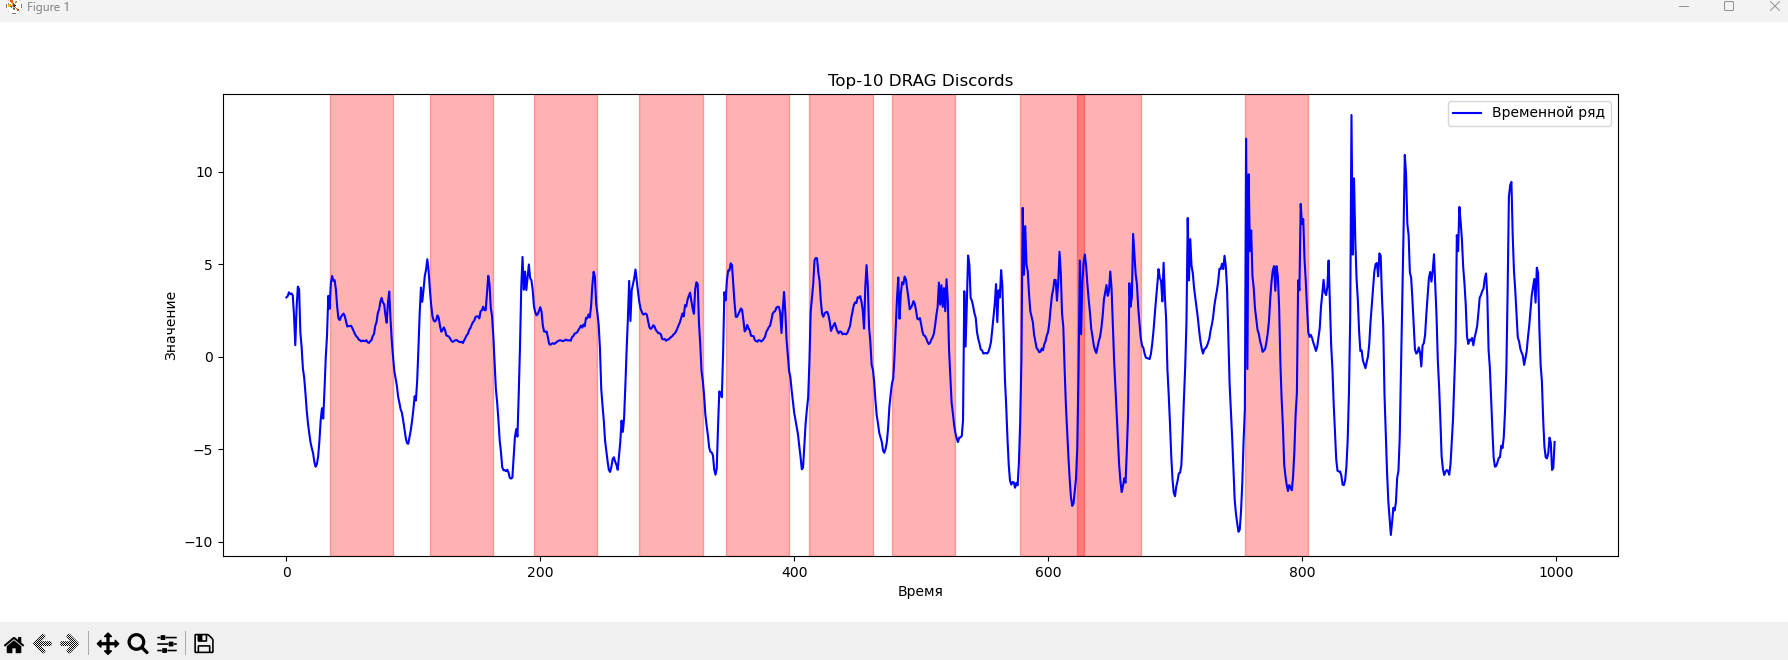

Найдите диссонансы набора такси NY. Визуализируйте найденные диссонансы для обоих наборов данных, сравните с результатами остальных методов. 


In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from stumpy import core
from modules.drag import DRAG

dataset_dir_path = Path('E:/maga/ryads/pr1/25-Chekrygin-TimeSeriesCourse/practice/03 Discords/datasets')
nyc_taxi = pd.read_csv(dataset_dir_path / 'nyc_taxi.csv', index_col=0).values[4000:8000, 0].astype(np.float64)

T = nyc_taxi
m = 50
topK = 10
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)

dis_idx = -np.ones(topK)
dis_nnDist = -np.ones(topK)
dis_nn_idx = -np.ones(topK)

r = 2 * np.sqrt(m)
minL = m
maxL = int(m + np.ceil(m*0.1))
cound_find_dis = 0

while cound_find_dis < topK:
    result = DRAG(data=T, m=minL, r=r, include=include)
    for diss, nnDist, nn in zip(*result):
        if cound_find_dis >= topK:
            break
        if nnDist < 0:
            continue
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis += 1
    r *= 0.5
    if r < 0.1:
        break

print('Количество найденных диссонансов:', cound_find_dis)
print('Индексы диссонансов:', dis_idx[:cound_find_dis])

plt.figure(figsize=(18, 6))
plt.plot(T, color='blue', label='NY Taxi')
for idx in dis_idx[:cound_find_dis]:
    plt.axvspan(int(idx), int(idx)+m, color='red', alpha=0.3)
plt.title(f'Top-{topK} DRAG Discords для NY Taxi')
plt.xlabel('Время')
plt.ylabel('Количество поездок')
plt.legend()
plt.show()


Количество найденных диссонансов: 10
Индексы диссонансов: [1910. 1952. 3120. 1934. 3142. 3183. 3156. 3237. 3197. 3280.]


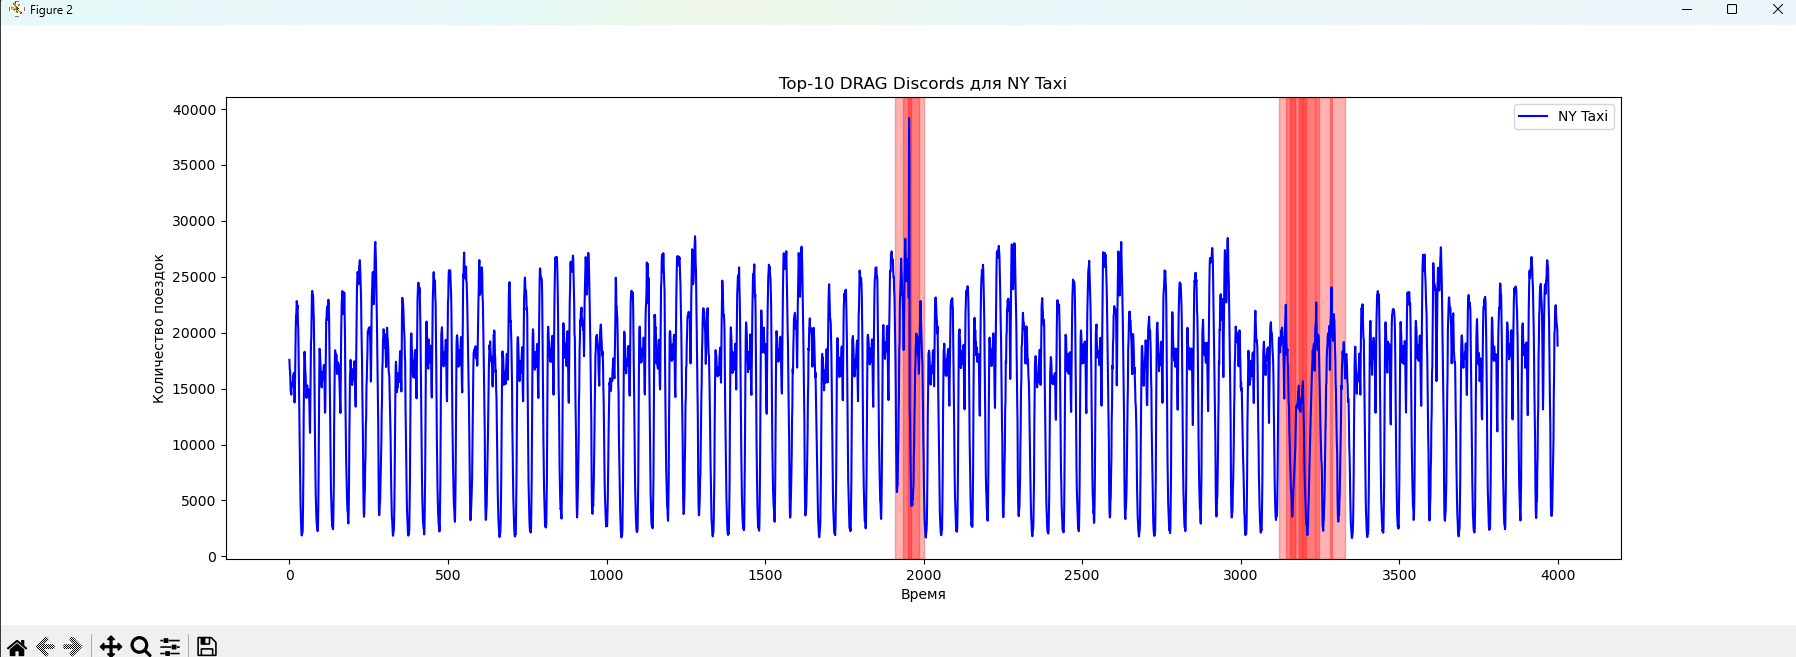